In [4]:
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
#import libpysal
#import esda
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [5]:
# data import
DATA_PATH = "../data/merged_ecec_province.geojson"
gdf = gpd.read_file(DATA_PATH)

e:\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "e:\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "e:\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "e:\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^

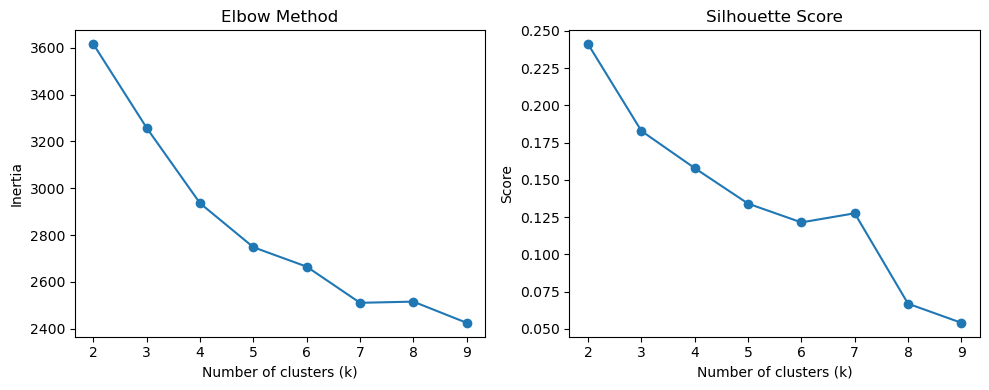

e:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


         population  unempl_rate  part_rate  empl_rate  empl_growth  \
cluster                                                               
0        1607081.62         5.70       0.06      69.08         2.43   
1         295491.33         9.76       0.05      56.78         0.96   
2         659778.88        14.84       0.04      45.07         3.27   
3         609034.88         4.54       0.06      68.13         2.76   
4         317221.07         6.28       0.05      67.06         2.12   

         inact_rate  fem_edu_rate  male_edu_rate  service_empl_rate   GDP  \
cluster                                                                     
0             26.76          0.24           0.21               0.74  0.05   
1             37.10          0.19           0.15               0.70  0.03   
2             47.17          0.17           0.14               0.70  0.02   
3             28.64          0.18           0.14               0.61  0.04   
4             28.46          0.18       

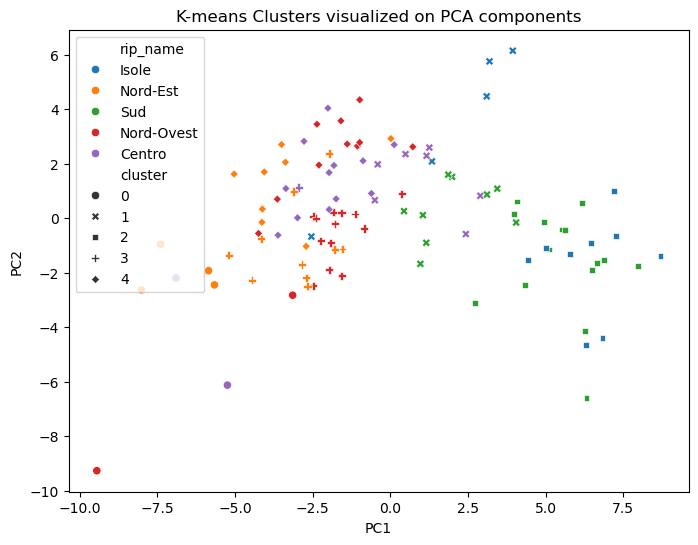

In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric variables (including fem_empl_rate)
X = gdf.select_dtypes(include='number').dropna()
X = X.drop(columns=['fem_empl_rate'])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3️Determine optimal number of clusters (optional – elbow + silhouette)
inertia = []
silhouette = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow and Silhouette
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(K_range, inertia, 'o-')
ax[0].set_title('Elbow Method')
ax[0].set_xlabel('Number of clusters (k)')
ax[0].set_ylabel('Inertia')

ax[1].plot(K_range, silhouette, 'o-')
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('Number of clusters (k)')
ax[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

# Choose the best k (e.g., from plots, suppose k=3)
best_k = 5
kmeans = KMeans(n_clusters=best_k, random_state=0)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to original data
gdf['cluster'] = clusters

# (Optional) Analyze mean values by cluster
cluster_summary = gdf.groupby('cluster')[X.columns].mean().round(2)
print(cluster_summary)

# (Optional) Visualize clusters on the first two principal components
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pcs, columns=['PC1', 'PC2'])
pca_df['cluster'] = clusters
pca_df['rip_name'] = gdf['rip_name']

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='rip_name', style='cluster', palette='tab10')
plt.title('K-means Clusters visualized on PCA components')
plt.show()


# Linear model  

Best alpha found: 0.0080

Non-zero coefficients (variables selected by Lasso):
empl_rate                        0.660392
ageing_index                     0.066785
coverage                         0.035213
per_capita_user_contribution     0.024987
ecec_participation               0.016080
private_coverage                 0.013476
per_capita_public_expenditure    0.012050
first_birth_maternal_age         0.005576
eco_urban_index                  0.002991
other_per_capita_expenditure     0.001582
GERD_total_intramural            0.000213
internet_coverage_rate          -0.000174
young_neet                      -0.000338
n_self_empl                     -0.000341
male_edu_rate                   -0.014674
fertility_rate                  -0.018707
n_members_family                -0.041239
avg_children_per_woman          -0.068054
fem_house_rate                  -0.263027
dtype: float64

Mean CV R²: 0.980 ± 0.010
Mean CV MSE: 0.016 ± 0.007


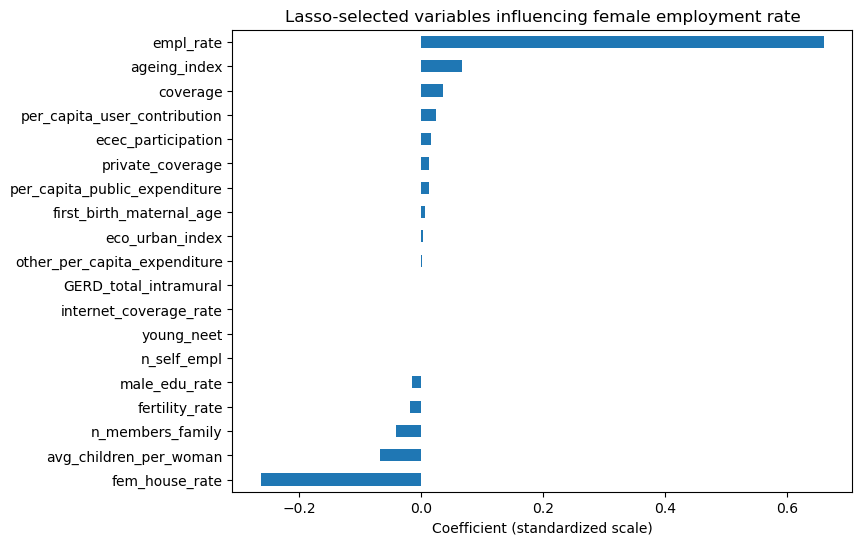

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, Lasso
from sklearn.model_selection import KFold, cross_val_score
import matplotlib.pyplot as plt

# 1️⃣ Prepare data
X = gdf.select_dtypes(include='number').drop(columns=['fem_empl_rate']).dropna()
y = gdf.loc[X.index, 'fem_empl_rate']
y = (y-np.mean(y))/np.std(y)

# 2️⃣ Standardize predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3️⃣ Cross-validated Lasso
cv = KFold(n_splits=10, shuffle=True, random_state=42)
lasso_cv = LassoCV(cv=cv, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y)

print(f"Best alpha found: {lasso_cv.alpha_:.4f}")

# 4️⃣ Refit on the whole dataset with optimal alpha
lasso_final = Lasso(alpha=lasso_cv.alpha_)
lasso_final.fit(X_scaled, y)

# 5️⃣ Inspect coefficients
coef = pd.Series(lasso_final.coef_, index=X.columns)
nonzero_coef = coef[coef != 0].sort_values(ascending=False)
print("\nNon-zero coefficients (variables selected by Lasso):")
print(nonzero_coef)

# 6️⃣ Model performance (CV again for reference)
r2_scores = cross_val_score(lasso_final, X_scaled, y, cv=cv, scoring='r2')
mse_scores = -cross_val_score(lasso_final, X_scaled, y, cv=cv, scoring='neg_mean_squared_error')
print(f"\nMean CV R²: {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")
print(f"Mean CV MSE: {np.mean(mse_scores):.3f} ± {np.std(mse_scores):.3f}")

# 7️⃣ Plot coefficients
plt.figure(figsize=(8,6))
nonzero_coef.sort_values().plot(kind='barh')
plt.title('Lasso-selected variables influencing female employment rate')
plt.xlabel('Coefficient (standardized scale)')
plt.show()
#